# 메이플스토리 주차 유저 클러스터링 — EDA

> **목적 1**: 기존 가설(H1/H2/H3) 외의 새로운 인사이트 발굴  
> **목적 2**: 각 가설의 검증 가능성 사전 확인 (샘플 충분성, 기대 빈도, 피처 분포)

**입력**: `../data/features_monthly.csv` — 1,497명 × 24개월 스냅샷 기반 피처  
**순서**: Sec0(설정) → Sec1(품질) → Sec2(단변량) → Sec3(이변량) → Sec4(직업/월드) → Sec5(레벨/H2) → Sec6(경험치) → Sec7(심볼) → Sec8(정체지수) → Sec9(가설검토) → Sec10(전처리결정)

## Sec 0. 환경 설정 및 데이터 로드

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')

# Windows 한국어 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

ARCANE_MAX = 120
DELTA_COLS = [
    'avg_monthly_delta_level',
    'avg_monthly_delta_combat_power',
    'avg_monthly_delta_union_level',
    'avg_monthly_delta_arcane_symbol',
    'avg_monthly_delta_authentic_symbol',
]
BAND_PALETTE = {
    '~260': '#4e79a7', '260~280': '#f28e2b',
    '280~300': '#e15759', '300+': '#76b7b2'
}
print('imports OK')

C:\Users\Ladinz\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Ladinz\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


imports OK


In [2]:
df = pd.read_csv('../data/features_monthly.csv', encoding='utf-8-sig')

# 레벨 구간 (전체 섹션에서 재사용)
df['level_band'] = pd.cut(
    df['level'],
    bins=[0, 260, 280, 300, 310],
    labels=['~260', '260~280', '280~300', '300+']
)

AUTHENTIC_MAX = max(int(df['authentic_symbol_score'].max()), 1)
print(f'로드 완료: {df.shape[0]}행 x {df.shape[1]}컬럼')
print(f'아케인 MAX={ARCANE_MAX}, 어센틱 MAX(실측)={AUTHENTIC_MAX}')
df.describe().T.round(2)

로드 완료: 1497행 x 19컬럼
아케인 MAX=120, 어센틱 MAX(실측)=88


,count,mean,std,min,25%,50%,75%,max
level,1497.0,2.835900e+02,1.430000e+01,205.00,2.800000e+02,2.880000e+02,2.930000e+02,3.000000e+02
union_level,1497.0,9.255940e+03,1.852110e+03,639.00,8.796000e+03,1.022900e+04,1.048900e+04,1.065100e+04
arcane_symbol_score,1497.0,1.130200e+02,2.023000e+01,0.00,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
authentic_symbol_score,1497.0,4.960000e+01,2.807000e+01,0.00,2.500000e+01,5.400000e+01,7.500000e+01,8.800000e+01
exp,1497.0,1.269483e+14,1.896080e+14,0.00,6.001414e+12,4.218628e+13,1.738805e+14,1.361699e+15
log_exp,1497.0,3.061000e+01,3.420000e+00,0.00,2.942000e+01,3.137000e+01,3.279000e+01,3.485000e+01
avg_monthly_delta_level,1463.0,5.000000e-01,1.020000e+00,0.00,1.500000e-01,3.500000e-01,4.800000e-01,1.594000e+01
avg_monthly_delta_combat_power,1464.0,5.292208e+06,9.080135e+06,-38486342.75,0.000000e+00,2.284400e+06,8.798732e+06,5.481096e+07
avg_monthly_delta_union_level,1463.0,4.564000e+01,7.353000e+01,-6.00,1.115000e+01,3.843000e+01,4.913000e+01,7.382000e+02
avg_monthly_delta_arcane_symbol,1497.0,1.370000e+00,2.170000e+00,-5.04,0.000000e+00,0.000000e+00,3.090000e+00,5.220000e+00


## Sec 1. 데이터 품질 진단

전처리 결정에 필요한 근거를 수집한다.

In [3]:
# 결측치 현황
null_s = df.isnull().sum()
null_pct = (null_s / len(df) * 100).round(1)
null_table = pd.DataFrame({'결측 수': null_s, '결측율(%)': null_pct})
print('=== 결측치 현황 ===')
display(null_table[null_table['결측 수'] > 0])

print(f'\nnum_valid_months 고유값: {df["num_valid_months"].unique()}')
print(f'first_valid_month 고유값: {df["first_valid_month"].unique()}')
print(f'last_valid_month  고유값: {df["last_valid_month"].unique()}')
print('\n→ 3개 메타 컬럼은 모두 단일 값 — 분석에서 제외 가능')

=== 결측치 현황 ===


,결측 수,결측율(%)
avg_monthly_delta_level,34,2.3
avg_monthly_delta_combat_power,33,2.2
avg_monthly_delta_union_level,34,2.3



num_valid_months 고유값: [24]
first_valid_month 고유값: <ArrowStringArray>
['2024-06']
Length: 1, dtype: str
last_valid_month  고유값: <ArrowStringArray>
['2026-05']
Length: 1, dtype: str

→ 3개 메타 컬럼은 모두 단일 값 — 분석에서 제외 가능


In [4]:
# NaN 행 레벨/직업 분포 — MAR 여부 검토
nan_mask = df[DELTA_COLS[:3]].isnull().any(axis=1)
print(f'NaN 행 수 (delta_level/cp/union 기준): {nan_mask.sum()}')

print('\n[NaN 행 레벨]')
print(df.loc[nan_mask, 'level'].describe().round(1))
print('\n[전체 레벨]')
print(df['level'].describe().round(1))

print('\n[레벨 구간별 NaN 비율(%)]')
nan_by_band = (
    df.groupby('level_band', observed=True)
    .apply(lambda g: g[DELTA_COLS[:3]].isnull().any(axis=1).mean() * 100)
    .round(1)
)
print(nan_by_band)
print('\n→ NaN 분포가 레벨 구간과 무관하면 listwise deletion 안전')

NaN 행 수 (delta_level/cp/union 기준): 34

[NaN 행 레벨]
count     34.0
mean     283.4
std        3.7
min      275.0
25%      282.0
50%      284.0
75%      285.0
max      290.0
Name: level, dtype: float64

[전체 레벨]
count    1497.0
mean      283.6
std        14.3
min       205.0
25%       280.0
50%       288.0
75%       293.0
max       300.0
Name: level, dtype: float64

[레벨 구간별 NaN 비율(%)]
level_band
~260       0.0
260~280    2.2
280~300    2.5
dtype: float64

→ NaN 분포가 레벨 구간과 무관하면 listwise deletion 안전


In [5]:
print('=== 특이 케이스 카탈로그 ===')
print(f'1. delta_cp < 0:          {(df["avg_monthly_delta_combat_power"] < 0).sum()}행  ({(df["avg_monthly_delta_combat_power"] < 0).mean()*100:.1f}%)')
print(f'2. delta_union < 0:       {(df["avg_monthly_delta_union_level"] < 0).sum()}행')
print(f'3. exp == 0:              {(df["exp"] == 0).sum()}행  (level==300: {(df["level"] == 300).sum()}행)')
print(f'4. delta_arcane < 0:      {(df["avg_monthly_delta_arcane_symbol"] < 0).sum()}행')
print(f'5. delta_authentic < 0:   {(df["avg_monthly_delta_authentic_symbol"] < 0).sum()}행')
print(f'6. arcane_score == {ARCANE_MAX}:  {(df["arcane_symbol_score"] == ARCANE_MAX).sum()}행  ({(df["arcane_symbol_score"] == ARCANE_MAX).mean()*100:.1f}%)')
print(f'7. delta_level == 0:      {(df["avg_monthly_delta_level"] == 0).sum()}행  ({(df["avg_monthly_delta_level"] == 0).mean()*100:.1f}%)')
print(f'8. delta_arcane == 0:     {(df["avg_monthly_delta_arcane_symbol"] == 0).sum()}행  ({(df["avg_monthly_delta_arcane_symbol"] == 0).mean()*100:.1f}%)')

=== 특이 케이스 카탈로그 ===
1. delta_cp < 0:          326행  (21.8%)
2. delta_union < 0:       3행
3. exp == 0:              7행  (level==300: 7행)
4. delta_arcane < 0:      1행
5. delta_authentic < 0:   1행
6. arcane_score == 120:  1256행  (83.9%)
7. delta_level == 0:      291행  (19.4%)
8. delta_arcane == 0:     985행  (65.8%)


In [6]:
# df_clean 생성 (주 분석용)
df_clean = df.dropna(subset=DELTA_COLS[:3]).copy()
# level==300은 exp==0 → log_exp 무의미
df_clean.loc[df_clean['level'] == 300, 'log_exp'] = np.nan

print(f'df_clean: {len(df_clean)}행 (원본 {len(df)}행 -> {len(df)-len(df_clean)}행 제거)')
print(f'\n[delta_level 분포]')
print(df_clean['avg_monthly_delta_level'].describe().round(3))

df_clean: 1463행 (원본 1497행 -> 34행 제거)

[delta_level 분포]
count    1463.000
mean        0.497
std         1.018
min         0.000
25%         0.146
50%         0.348
75%         0.478
max        15.941
Name: avg_monthly_delta_level, dtype: float64


## Sec 2. 핵심 피처 단변량 분포

H1 군집 분리 가능성의 시각적 근거를 확보한다.

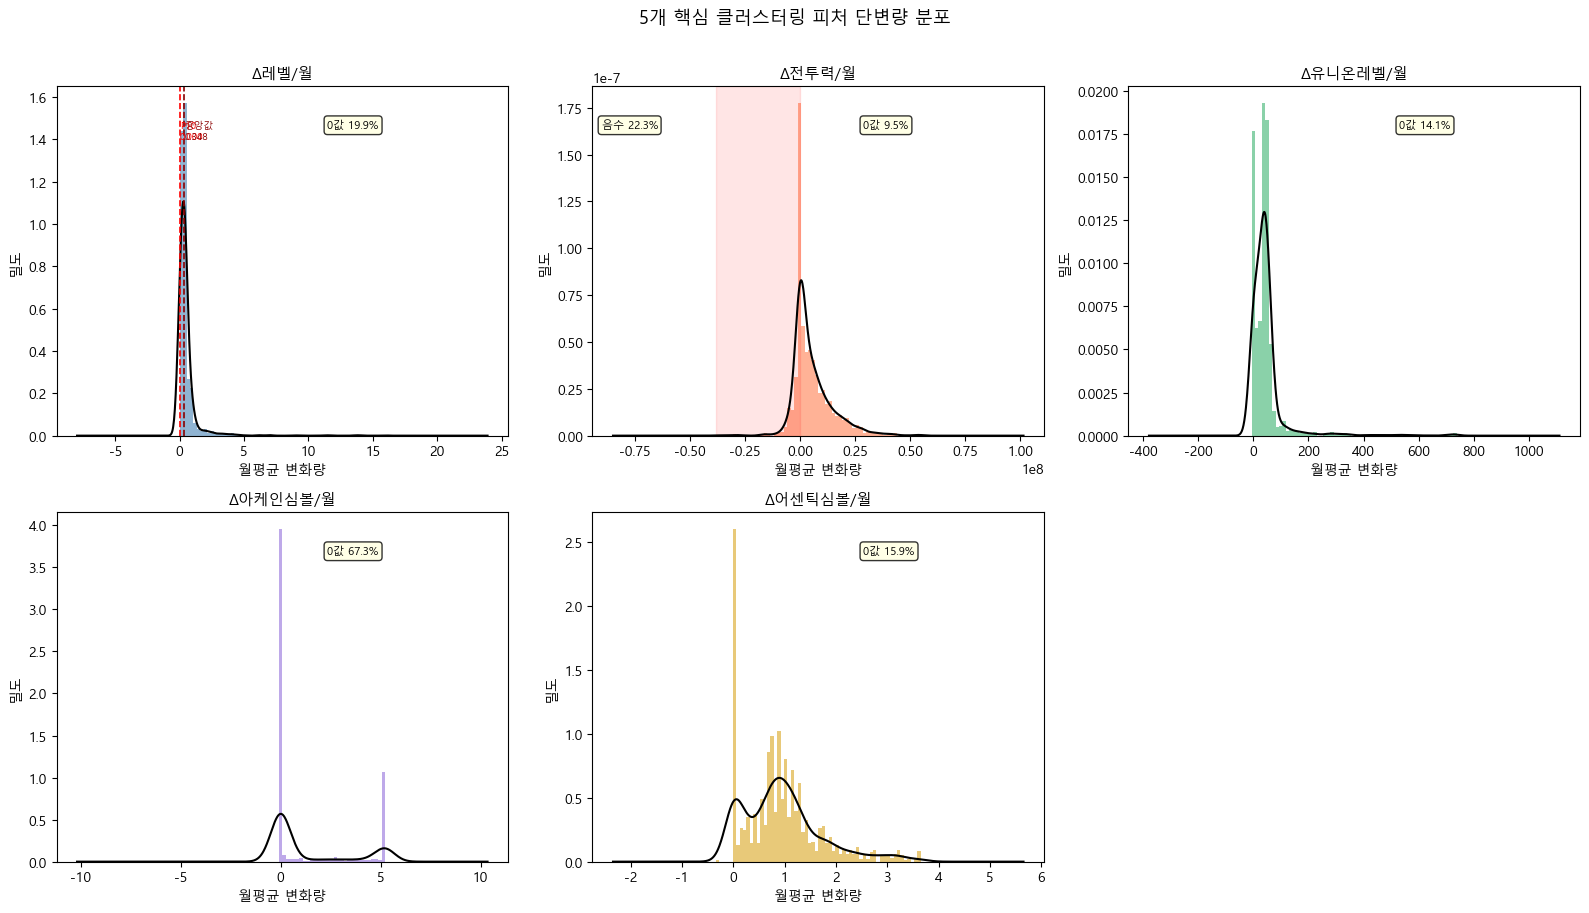

In [7]:
titles = ['Δ레벨/월', 'Δ전투력/월', 'Δ유니온레벨/월', 'Δ아케인심볼/월', 'Δ어센틱심볼/월']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, title, color) in enumerate(zip(DELTA_COLS, titles, colors)):
    ax = axes[i]
    data = df_clean[col].dropna()

    ax.hist(data, bins=60, color=color, alpha=0.6, density=True)
    data.plot.kde(ax=ax, color='black', lw=1.5)

    # Δ레벨: 분위수 표시
    if col == 'avg_monthly_delta_level':
        for q, lbl, c in [(0.1,'P10','red'), (0.5,'중앙값','darkred')]:
            v = data.quantile(q)
            ax.axvline(v, color=c, lw=1.2, ls='--')
            ax.text(v+0.01, ax.get_ylim()[1]*0.85, f'{lbl}\n{v:.3f}', fontsize=7, color=c)

    # delta_cp: 음수 구간 음영
    if col == 'avg_monthly_delta_combat_power':
        ax.axvspan(data.min(), 0, alpha=0.1, color='red')
        ax.text(0.02, 0.88, f'음수 {(data<0).mean()*100:.1f}%',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

    zero_rate = (data == 0).mean() * 100
    if zero_rate > 5:
        ax.text(0.6, 0.88, f'0값 {zero_rate:.1f}%',
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('월평균 변화량')
    ax.set_ylabel('밀도')

axes[-1].set_visible(False)
plt.suptitle('5개 핵심 클러스터링 피처 단변량 분포', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

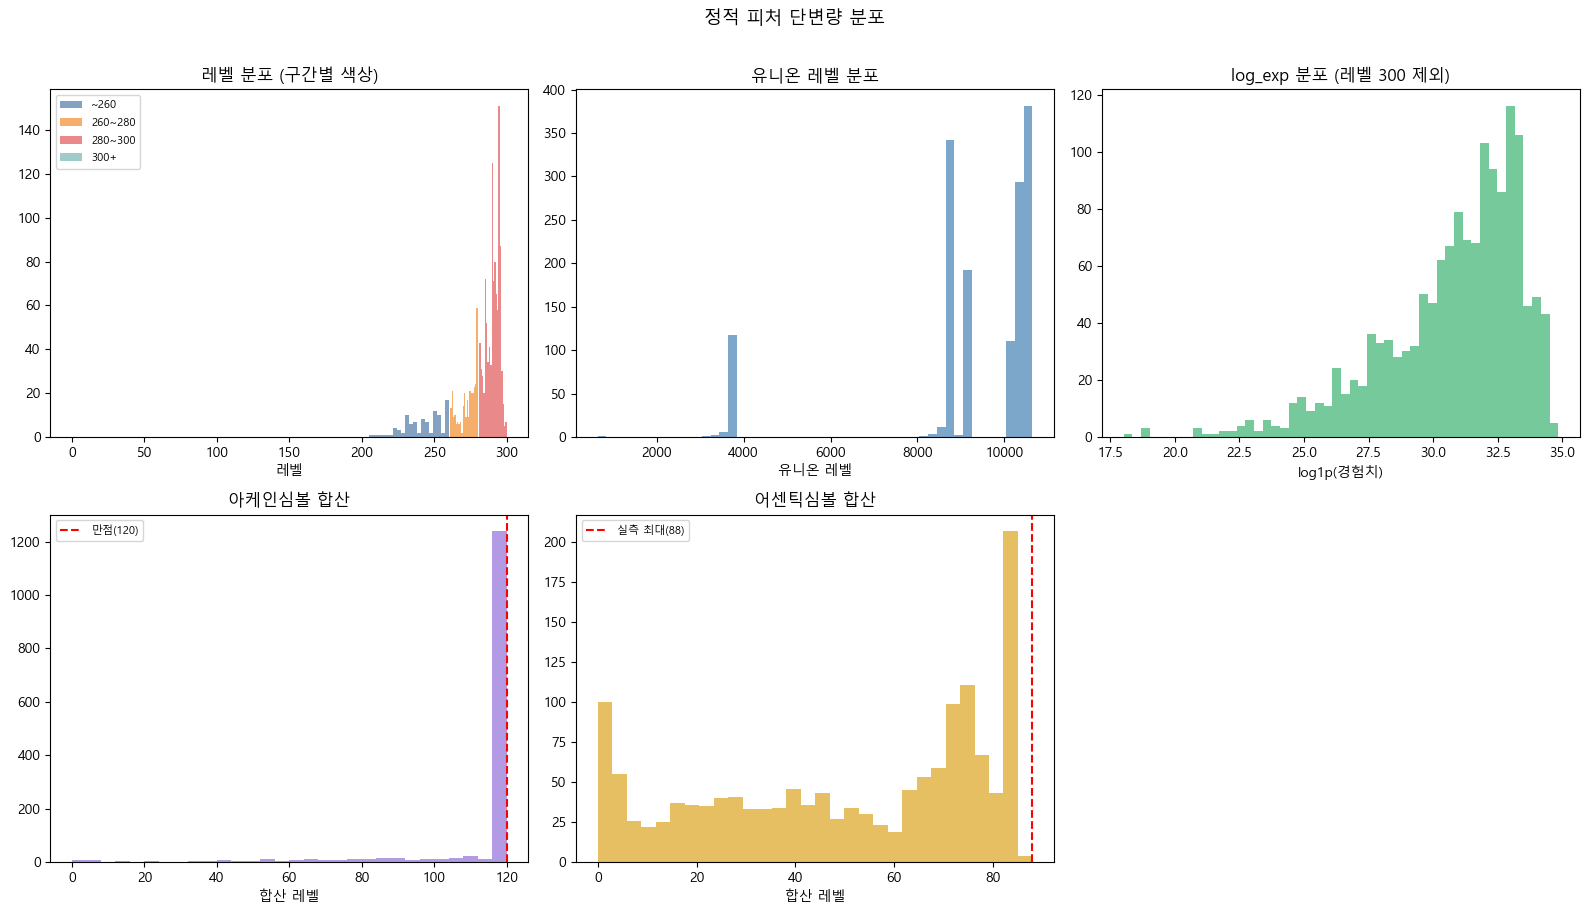

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. 레벨 (구간별 색상)
for band, color in BAND_PALETTE.items():
    subset = df_clean[df_clean['level_band'] == band]['level']
    axes[0].hist(subset, bins=20, color=color, alpha=0.7, label=band)
axes[0].set_title('레벨 분포 (구간별 색상)')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('레벨')

# 2. 유니온 레벨
axes[1].hist(df_clean['union_level'].dropna(), bins=50, color='steelblue', alpha=0.7)
axes[1].set_title('유니온 레벨 분포')
axes[1].set_xlabel('유니온 레벨')

# 3. log_exp (level < 300)
log_data = df_clean.loc[df_clean['level'] < 300, 'log_exp'].dropna()
axes[2].hist(log_data, bins=50, color='mediumseagreen', alpha=0.7)
axes[2].set_title('log_exp 분포 (레벨 300 제외)')
axes[2].set_xlabel('log1p(경험치)')

# 4. 아케인심볼 합산
axes[3].hist(df_clean['arcane_symbol_score'], bins=30, color='mediumpurple', alpha=0.7)
axes[3].axvline(ARCANE_MAX, color='red', lw=1.5, ls='--', label=f'만점({ARCANE_MAX})')
axes[3].set_title('아케인심볼 합산')
axes[3].legend(fontsize=8)
axes[3].set_xlabel('합산 레벨')

# 5. 어센틱심볼 합산
axes[4].hist(df_clean['authentic_symbol_score'], bins=30, color='goldenrod', alpha=0.7)
axes[4].axvline(AUTHENTIC_MAX, color='red', lw=1.5, ls='--', label=f'실측 최대({AUTHENTIC_MAX})')
axes[4].set_title('어센틱심볼 합산')
axes[4].legend(fontsize=8)
axes[4].set_xlabel('합산 레벨')

axes[5].set_visible(False)
plt.suptitle('정적 피처 단변량 분포', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Sec 3. 이변량 관계 분석

피처 간 다중공선성 및 예상치 못한 관계를 확인한다.

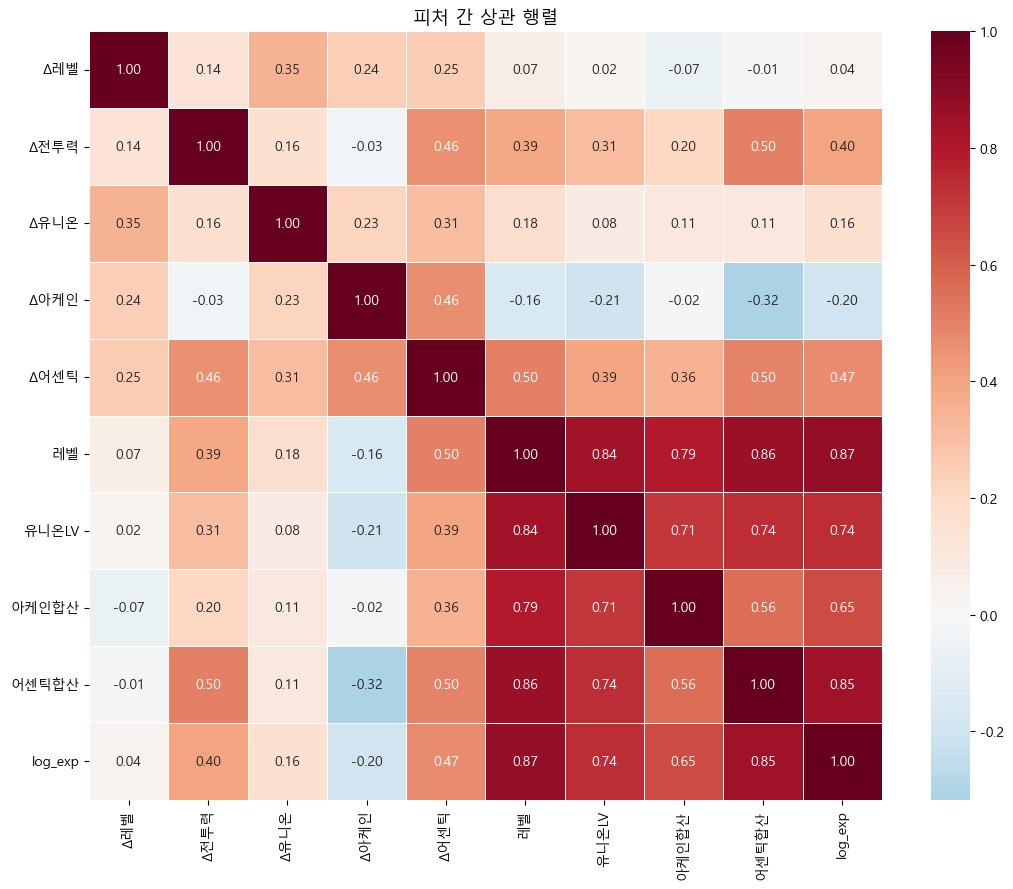


주목할 상관 쌍:
  Dlevel x Dunion_level: r = 0.348
  log_exp x authentic_symbol_score: r = 0.848
  Dlevel x Dcombat_power: r = 0.137


In [9]:
num_cols = DELTA_COLS + ['level', 'union_level', 'arcane_symbol_score',
                          'authentic_symbol_score', 'log_exp']
col_labels = ['Δ레벨', 'Δ전투력', 'Δ유니온', 'Δ아케인', 'Δ어센틱',
              '레벨', '유니온LV', '아케인합산', '어센틱합산', 'log_exp']

corr = df_clean[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=col_labels, yticklabels=col_labels,
            linewidths=0.5, ax=ax)
ax.set_title('피처 간 상관 행렬', fontsize=13)
plt.tight_layout()
plt.show()

print('\n주목할 상관 쌍:')
pairs = [
    ('avg_monthly_delta_level', 'avg_monthly_delta_union_level'),
    ('log_exp', 'authentic_symbol_score'),
    ('avg_monthly_delta_level', 'avg_monthly_delta_combat_power'),
]
for c1, c2 in pairs:
    r = df_clean[[c1, c2]].corr().iloc[0, 1]
    short1 = c1.replace('avg_monthly_delta_', 'D')
    short2 = c2.replace('avg_monthly_delta_', 'D')
    print(f'  {short1} x {short2}: r = {r:.3f}')

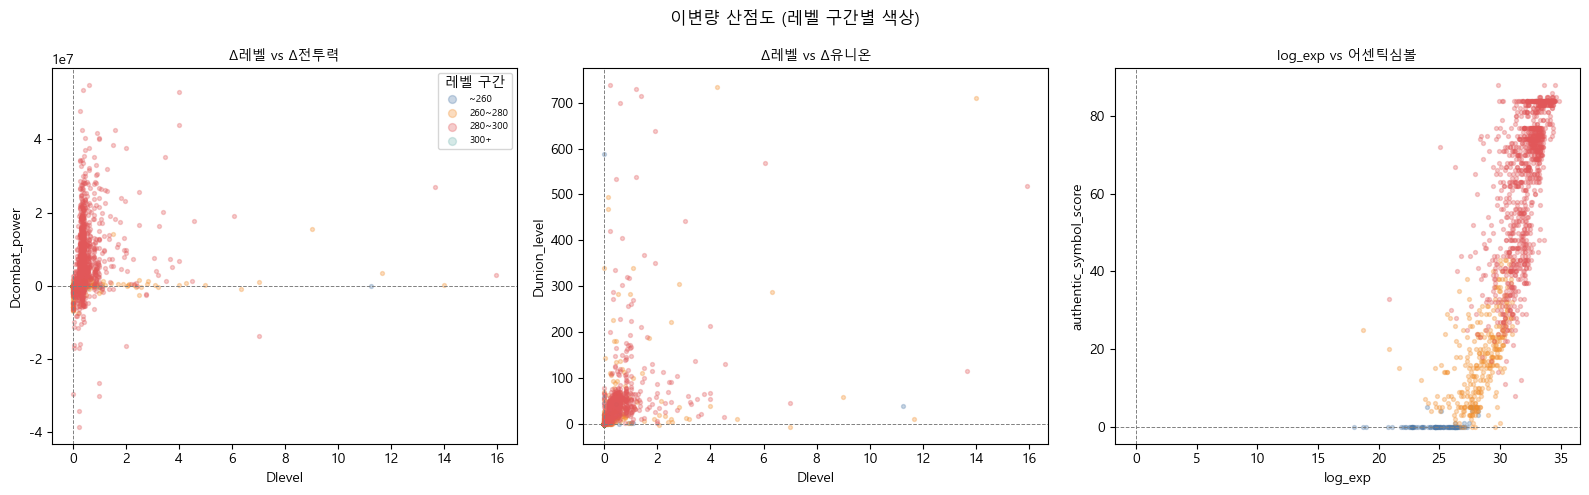

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_pairs = [
    ('avg_monthly_delta_level', 'avg_monthly_delta_combat_power', 'Δ레벨 vs Δ전투력'),
    ('avg_monthly_delta_level', 'avg_monthly_delta_union_level', 'Δ레벨 vs Δ유니온'),
    ('log_exp', 'authentic_symbol_score', 'log_exp vs 어센틱심볼'),
]

for ax, (x, y, title) in zip(axes, scatter_pairs):
    for band, color in BAND_PALETTE.items():
        sub = df_clean[df_clean['level_band'] == band]
        ax.scatter(sub[x], sub[y], c=color, alpha=0.3, s=8, label=band)
    ax.set_xlabel(x.replace('avg_monthly_delta_', 'D'))
    ax.set_ylabel(y.replace('avg_monthly_delta_', 'D'))
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')

axes[0].legend(title='레벨 구간', fontsize=7, markerscale=2)
plt.suptitle('이변량 산점도 (레벨 구간별 색상)', fontsize=12)
plt.tight_layout()
plt.show()

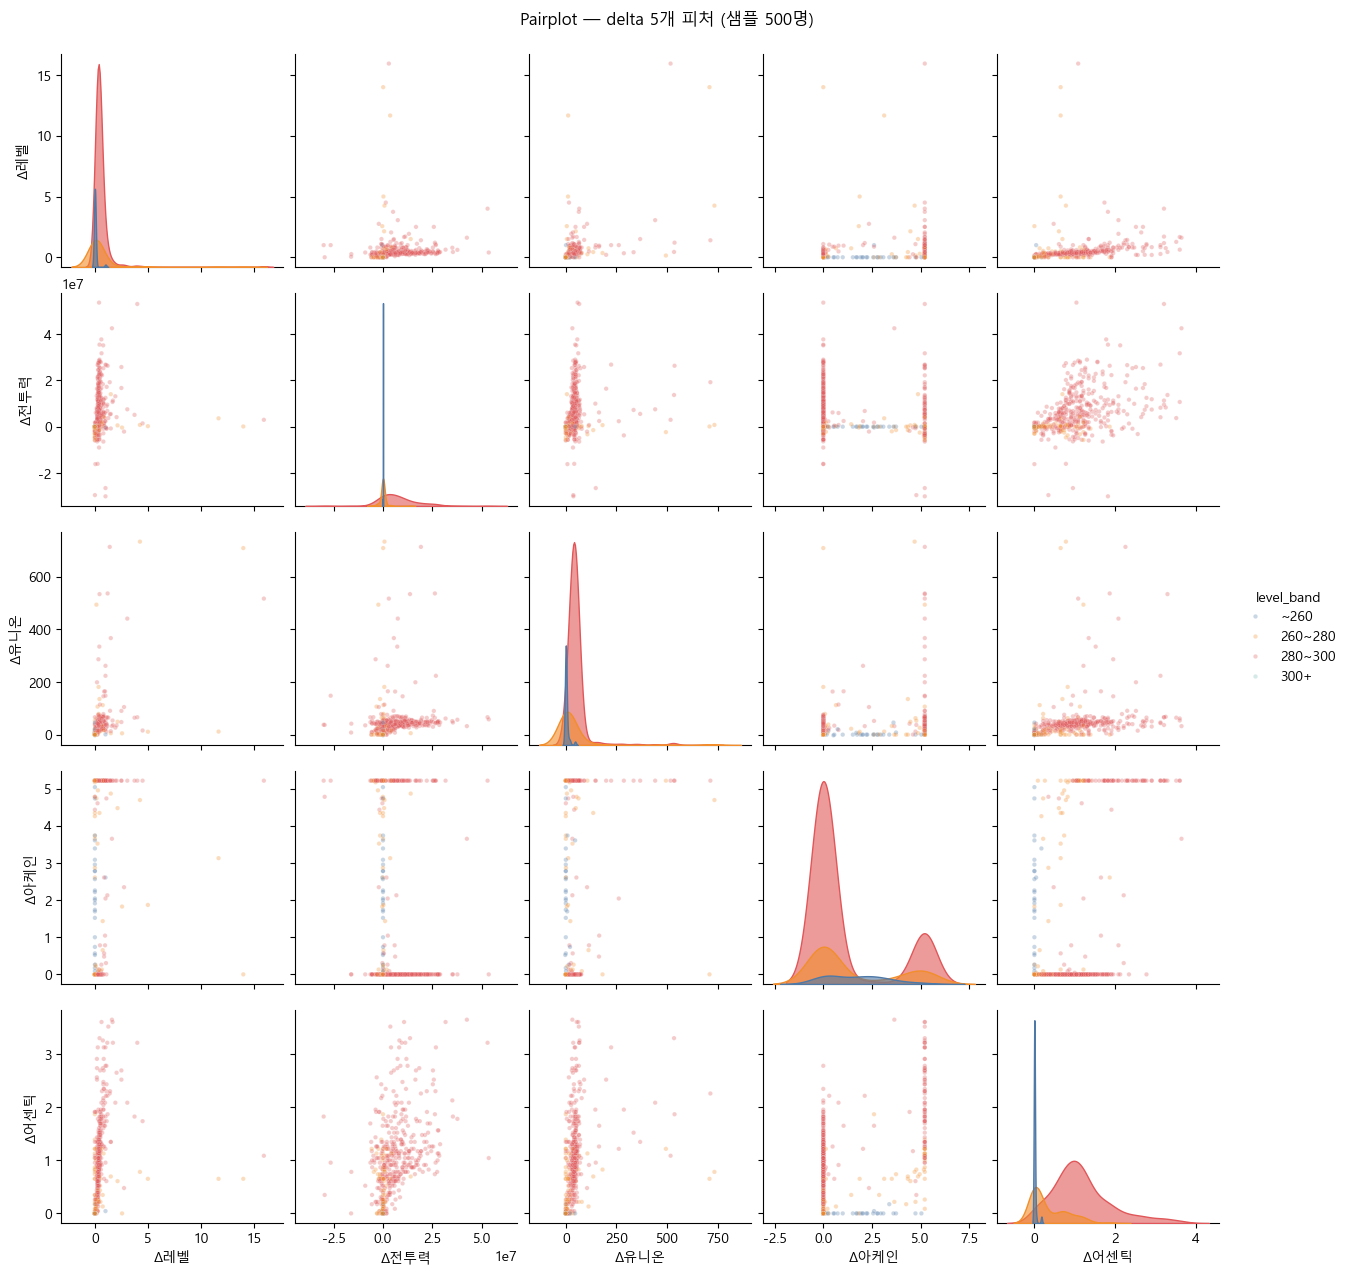

→ 좌하단 군집(Δ레벨~0, Δ전투력~0)이 뚜렷하면 H1 클러스터 분리 가능성 높음


In [11]:
# Pairplot — delta 5개 (샘플 500)
sample_n = min(500, len(df_clean))
df_pair = (
    df_clean[DELTA_COLS + ['level_band']]
    .dropna()
    .sample(sample_n, random_state=42)
    .copy()
)
df_pair.columns = ['Δ레벨', 'Δ전투력', 'Δ유니온', 'Δ아케인', 'Δ어센틱', 'level_band']

g = sns.pairplot(
    df_pair, hue='level_band', palette=BAND_PALETTE,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kws={'alpha': 0.6}
)
g.figure.suptitle(f'Pairplot — delta 5개 피처 (샘플 {sample_n}명)', y=1.02, fontsize=12)
plt.show()
print('→ 좌하단 군집(Δ레벨~0, Δ전투력~0)이 뚜렷하면 H1 클러스터 분리 가능성 높음')

In [12]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df_clean[DELTA_COLS].dropna()
    vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_df = pd.DataFrame({'피처': DELTA_COLS, 'VIF': np.round(vif_vals, 2)})
    display(vif_df)
    high = vif_df[vif_df['VIF'] > 5]
    if len(high):
        print(f'\n⚠ VIF > 5 피처: {high["피처"].tolist()} -> PCA 또는 피처 제거 검토')
    else:
        print('\n✓ 모든 VIF ≤ 5 — 다중공선성 문제 없음')
except ImportError:
    r = df_clean['avg_monthly_delta_level'].corr(df_clean['avg_monthly_delta_union_level'])
    print(f'statsmodels 미설치. Δ레벨-Δ유니온 상관 r={r:.3f}')
    print('pip install statsmodels 후 재실행')

,피처,VIF
0,avg_monthly_delta_level,1.47
1,avg_monthly_delta_combat_power,1.88
2,avg_monthly_delta_union_level,1.66
3,avg_monthly_delta_arcane_symbol,1.99
4,avg_monthly_delta_authentic_symbol,3.41



✓ 모든 VIF ≤ 5 — 다중공선성 문제 없음


## Sec 4. 직업 / 월드 분포 분석

H2 직업 그루핑 타당성 확인 및 샘플링 편향 탐색.

In [13]:
CLASS_GROUP_MAP = {
    # 전사계열
    '히어로':'전사', '팔라딘':'전사', '다크나이트':'전사',
    '소울마스터':'전사', '블래스터':'전사', '데몬슬레이어':'전사',
    '데몬어벤져':'전사', '아란':'전사', '카이저':'전사',
    '제로':'전사', '아델':'전사', '호영':'전사',
    # 마법사계열
    '아크메이지(불,독)':'마법사', '아크메이지(썬,콜)':'마법사', '비숍':'마법사',
    '배틀메이지':'마법사', '에반':'마법사', '루미너스':'마법사',
    '플레임위자드':'마법사', '키네시스':'마법사', '일리움':'마법사',
    '라라':'마법사', '칼리':'마법사',
    # 궁수계열
    '보우마스터':'궁수', '신궁':'궁수', '패스파인더':'궁수',
    '윈드브레이커':'궁수', '와일드헌터':'궁수', '메르세데스':'궁수',
    '카인':'궁수', '카데나':'궁수',
    # 도적계열
    '나이트로드':'도적', '섀도어':'도적', '듀얼블레이더':'도적',
    '나이트워커':'도적', '제논':'도적', '은월':'도적',
    '팬텀':'도적', '미하일':'도적',
    # 해적계열
    '바이퍼':'해적', '캡틴':'해적', '캐논마스터':'해적',
    '스트라이커':'해적', '메카닉':'해적', '엔젤릭버스터':'해적',
    '아크':'해적', '렌':'해적',
    # 기타
    '초보자':'기타',
}
df_clean['class_group'] = df_clean['character_class'].map(CLASS_GROUP_MAP).fillna('기타')

unmapped = [c for c in df_clean[df_clean['class_group']=='기타']['character_class'].unique()
            if c != '초보자']
if unmapped:
    print(f'⚠ 미매핑 직업 (기타 처리됨): {unmapped}')
    print('  CLASS_GROUP_MAP에 추가 후 재실행하세요.')
else:
    print('✓ 초보자 외 미매핑 직업 없음')
print('\n계열별 인원:')
print(df_clean['class_group'].value_counts().to_string())

✓ 초보자 외 미매핑 직업 없음

계열별 인원:
class_group
전사     372
해적     307
마법사    301
도적     300
궁수     182
기타       1


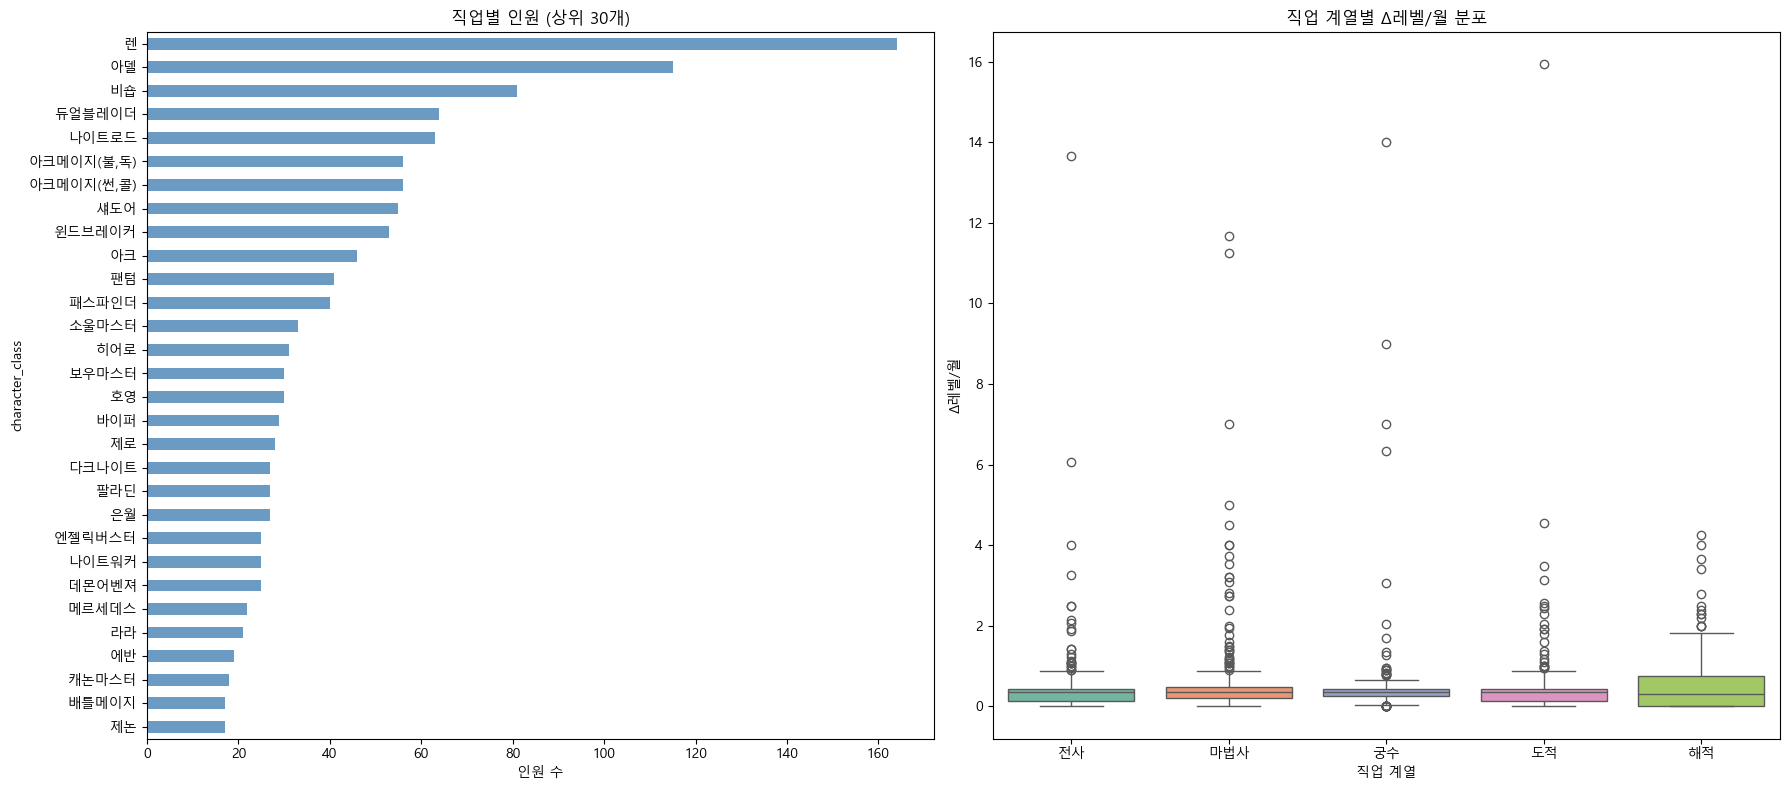

[계열별 평균 Δ레벨]
class_group
전사     0.421
도적     0.464
해적     0.478
궁수     0.573
마법사    0.596


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 왼쪽: 직업별 인원 (상위 30)
class_cnt = df_clean['character_class'].value_counts().head(30)
class_cnt.plot.barh(ax=axes[0], color='steelblue', alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_title('직업별 인원 (상위 30개)')
axes[0].set_xlabel('인원 수')

# 오른쪽: 계열별 Δ레벨 boxplot
group_order = ['전사', '마법사', '궁수', '도적', '해적']
df_grp = df_clean[df_clean['class_group'].isin(group_order)]
sns.boxplot(data=df_grp, x='class_group', y='avg_monthly_delta_level',
            order=group_order, ax=axes[1], palette='Set2')
axes[1].set_title('직업 계열별 Δ레벨/월 분포')
axes[1].set_xlabel('직업 계열')
axes[1].set_ylabel('Δ레벨/월')

plt.tight_layout()
plt.show()

print('[계열별 평균 Δ레벨]')
print(df_grp.groupby('class_group')['avg_monthly_delta_level'].mean().sort_values().round(3).to_string())

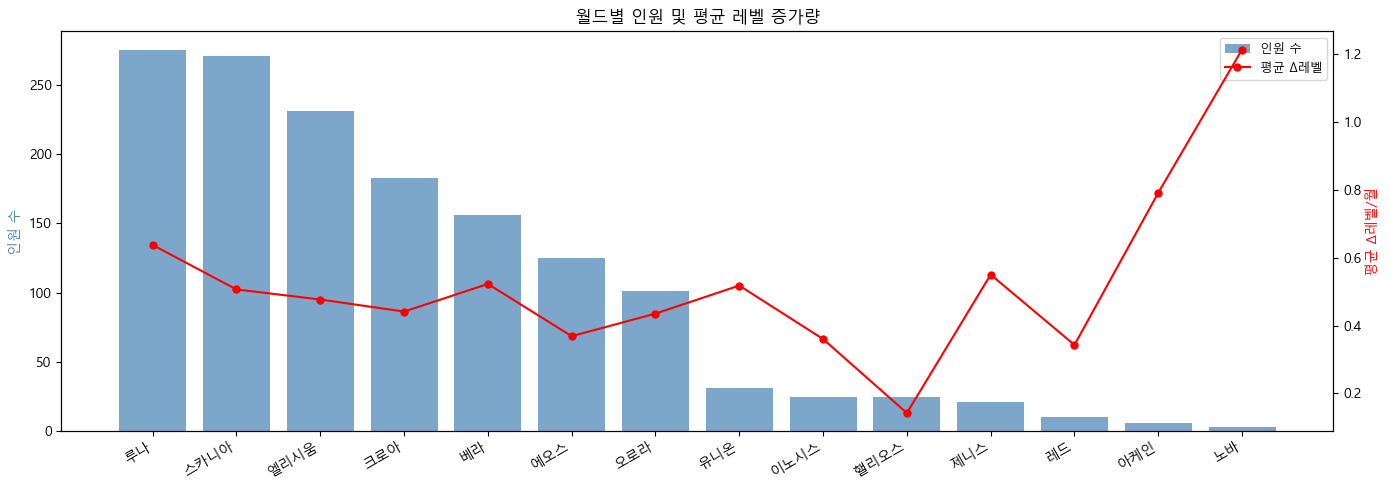

In [15]:
world_stats = (
    df_clean.groupby('world_name')
    .agg(인원=('character_name', 'count'),
         평균_delta_level=('avg_monthly_delta_level', 'mean'))
    .sort_values('인원', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
worlds = world_stats.index.tolist()
x = range(len(worlds))
ax1.bar(x, world_stats['인원'], color='steelblue', alpha=0.7, label='인원 수')
ax2.plot(x, world_stats['평균_delta_level'], 'r-o', lw=1.5, ms=5, label='평균 Δ레벨')
ax1.set_xticks(x)
ax1.set_xticklabels(worlds, rotation=30, ha='right')
ax1.set_ylabel('인원 수', color='steelblue')
ax2.set_ylabel('평균 Δ레벨/월', color='red')
ax1.set_title('월드별 인원 및 평균 레벨 증가량')
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Sec 5. 레벨 구간 분석 및 H2 Chi-Square 사전 검토

가설 H2 검증 가능성을 수치로 판단한다.

[레벨 구간별 샘플 수]
level_band
~260         98
260~280     317
280~300    1048
300+          0

280+ 비율: 75.7%  <- 유니온 랭킹 기반 샘플링 편향


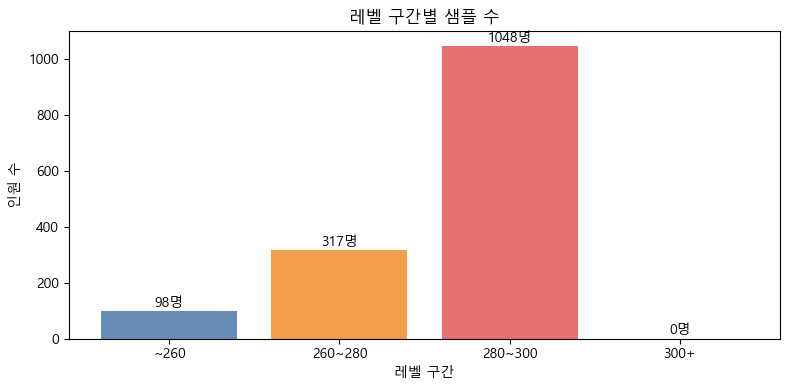


주차 프록시 (Δ레벨 ≤ 0.1): 347명 (23.7%)


In [16]:
band_counts = df_clean['level_band'].value_counts().sort_index()
print('[레벨 구간별 샘플 수]')
print(band_counts.to_string())
print(f'\n280+ 비율: {(df_clean["level"] >= 280).mean()*100:.1f}%  <- 유니온 랭킹 기반 샘플링 편향')

fig, ax = plt.subplots(figsize=(8, 4))
bands = band_counts.index.tolist()
colors_band = [BAND_PALETTE[b] for b in bands]
bars = ax.bar(bands, band_counts.values, color=colors_band, alpha=0.85)
for bar, cnt in zip(bars, band_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{cnt}명', ha='center', va='bottom', fontsize=10)
ax.set_title('레벨 구간별 샘플 수')
ax.set_xlabel('레벨 구간')
ax.set_ylabel('인원 수')
plt.tight_layout()
plt.show()

# 주차 프록시 (Sec 9에서도 재사용)
parked_proxy = df_clean['avg_monthly_delta_level'] <= 0.1
print(f'\n주차 프록시 (Δ레벨 ≤ 0.1): {parked_proxy.sum()}명 ({parked_proxy.mean()*100:.1f}%)')

In [17]:
# H2 Chi-Square 기대 빈도 검토 — 레벨 구간
ct_level = pd.crosstab(
    df_clean['level_band'],
    parked_proxy.map({True:'주차_프록시', False:'일반'})
)
print('[레벨 구간 x 주차 프록시 교차표]')
display(ct_level)

chi2, p, dof, expected = chi2_contingency(ct_level)
print(f'\nChi2={chi2:.2f}, p={p:.4f}, dof={dof}')
exp_df = pd.DataFrame(expected, index=ct_level.index, columns=ct_level.columns).round(2)
print('\n[기대 빈도]')
display(exp_df)

min_exp = expected.min()
print(f'\n최소 기대 빈도: {min_exp:.2f}')
if min_exp >= 5:
    print('✓ 모든 셀 기대 빈도 >= 5 -> H2 레벨 구간 Chi-Square 가능')
else:
    print('⚠ 최소 기대 빈도 < 5 -> 구간 합산 또는 Yates 보정 / Fisher exact test 검토')

[레벨 구간 x 주차 프록시 교차표]


avg_monthly_delta_level,일반,주차_프록시
level_band,,
~260,11,87
260~280,121,196
280~300,984,64



Chi2=663.39, p=0.0000, dof=2

[기대 빈도]


avg_monthly_delta_level,일반,주차_프록시
level_band,,
~260,74.76,23.24
260~280,241.81,75.19
280~300,799.43,248.57



최소 기대 빈도: 23.24
✓ 모든 셀 기대 빈도 >= 5 -> H2 레벨 구간 Chi-Square 가능


In [18]:
# H2 Chi-Square 기대 빈도 검토 — 직업 계열
df_cls = df_clean[df_clean['class_group'] != '기타']
ct_class = pd.crosstab(
    df_cls['class_group'],
    parked_proxy.loc[df_cls.index].map({True:'주차_프록시', False:'일반'})
)
print('[직업 계열 x 주차 프록시 교차표]')
display(ct_class)

chi2c, pc, dofc, expectedc = chi2_contingency(ct_class)
print(f'\nChi2={chi2c:.2f}, p={pc:.4f}, dof={dofc}')
min_exp_c = expectedc.min()
print(f'최소 기대 빈도: {min_exp_c:.2f}')
if min_exp_c >= 5:
    print('✓ 모든 셀 기대 빈도 >= 5 -> H2 직업 계열 Chi-Square 가능 (초보자 제외)')
else:
    print('⚠ 최소 기대 빈도 < 5 -> 계열 추가 합산 검토')

[직업 계열 x 주차 프록시 교차표]


avg_monthly_delta_level,일반,주차_프록시
class_group,,
궁수,155,27
도적,226,74
마법사,245,56
전사,281,91
해적,208,99



Chi2=24.88, p=0.0001, dof=4
최소 기대 빈도: 43.20
✓ 모든 셀 기대 빈도 >= 5 -> H2 직업 계열 Chi-Square 가능 (초보자 제외)


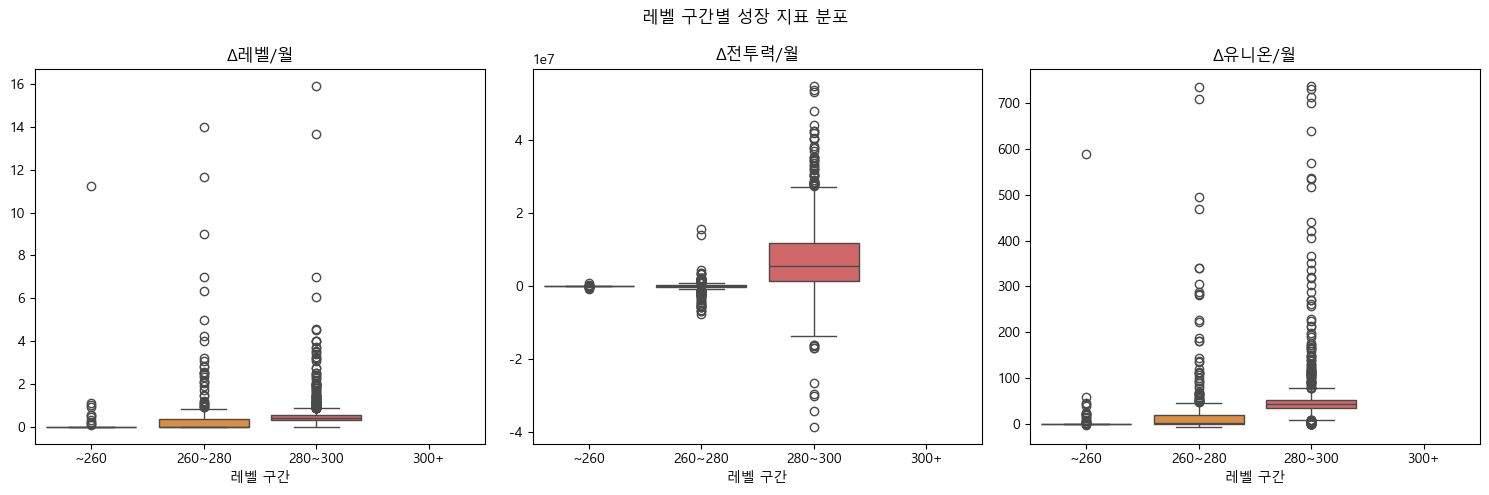

In [19]:
band_order = ['~260', '260~280', '280~300', '300+']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
delta_targets = [
    ('avg_monthly_delta_level', 'Δ레벨/월'),
    ('avg_monthly_delta_combat_power', 'Δ전투력/월'),
    ('avg_monthly_delta_union_level', 'Δ유니온/월'),
]
for ax, (col, title) in zip(axes, delta_targets):
    sns.boxplot(data=df_clean, x='level_band', y=col,
                order=band_order, ax=ax,
                palette=BAND_PALETTE)
    ax.set_title(title)
    ax.set_xlabel('레벨 구간')
    ax.set_ylabel('')
plt.suptitle('레벨 구간별 성장 지표 분포', fontsize=12)
plt.tight_layout()
plt.show()

## Sec 6. 경험치 신호 분석 (가설 외 탐색)

**가설**: 같은 레벨에서 경험치가 낮으면 해당 레벨에 오래 머문 유저(= 주차 후보)

In [20]:
# 레벨 내 경험치 상대 위치 (백분위)
df_exp = df_clean[df_clean['level'] < 300].copy()
df_exp['exp_rank_within_level'] = (
    df_exp.groupby('level')['log_exp']
    .rank(pct=True, na_option='keep')
)

valid_exp = df_exp[['avg_monthly_delta_level', 'exp_rank_within_level']].dropna()
r_exp, p_exp = spearmanr(valid_exp.iloc[:, 0], valid_exp.iloc[:, 1])
print(f'Δ레벨 vs exp_rank_within_level — Spearman r={r_exp:.3f}, p={p_exp:.4f}')
print(f'유효 샘플: {len(valid_exp)}명')
print(f'\n[해석]')
print('exp_rank_within_level 낮음 = 같은 레벨 내에서 경험치 적음')
print('= 최근에 해당 레벨에 진입 (성장 중인 유저)')
print('exp_rank_within_level 높음 = 같은 레벨에 오래 머뭄 (주차 후보?)')
if r_exp > 0:
    print(f'\n-> r={r_exp:.3f} > 0: Δ레벨 높을수록 경험치도 높음 (성장 + 누적 exp)')
    print('   주차 신호로서 단독 사용 어려움 — 클러스터와 교차 검증 필요')
else:
    print(f'\n-> r={r_exp:.3f} < 0: Δ레벨 낮을수록 경험치 높음 = 주차 신호로서 활용 가능')

Δ레벨 vs exp_rank_within_level — Spearman r=-0.113, p=0.0000
유효 샘플: 1456명

[해석]
exp_rank_within_level 낮음 = 같은 레벨 내에서 경험치 적음
= 최근에 해당 레벨에 진입 (성장 중인 유저)
exp_rank_within_level 높음 = 같은 레벨에 오래 머뭄 (주차 후보?)

-> r=-0.113 < 0: Δ레벨 낮을수록 경험치 높음 = 주차 신호로서 활용 가능


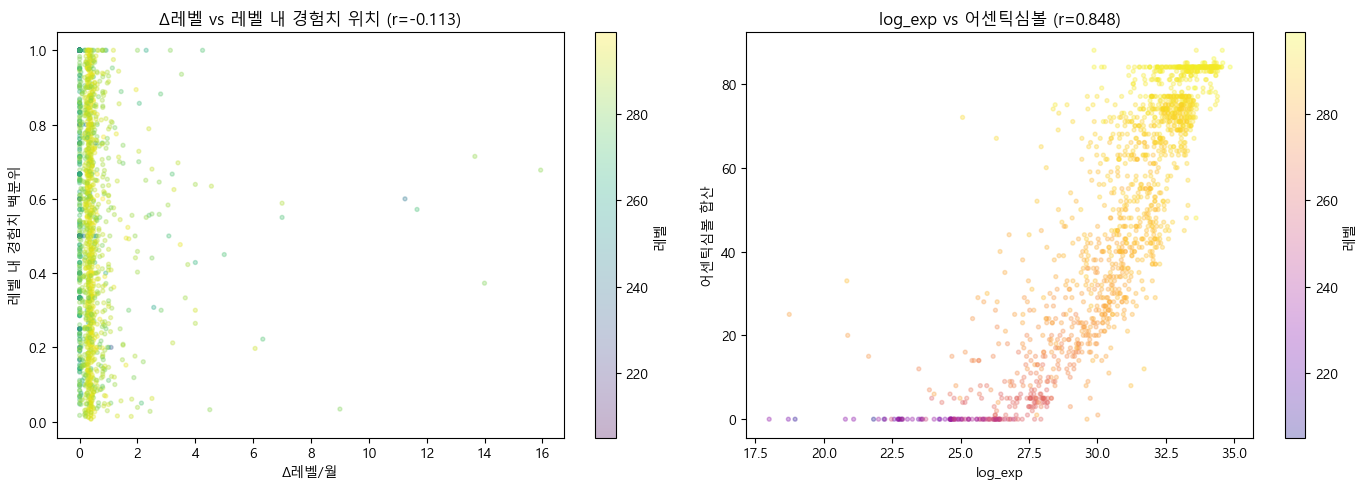

-> r=0.848: 강한 상관 - 두 변수는 중복 정보 가능성 높음
   클러스터링 피처로 log_exp와 authentic을 동시에 사용하면 정보 과다 계상 위험


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Δ레벨 vs exp_rank
sc = axes[0].scatter(
    df_exp['avg_monthly_delta_level'],
    df_exp['exp_rank_within_level'],
    c=df_exp['level'], cmap='viridis', alpha=0.3, s=8
)
plt.colorbar(sc, ax=axes[0], label='레벨')
axes[0].set_xlabel('Δ레벨/월')
axes[0].set_ylabel('레벨 내 경험치 백분위')
axes[0].set_title(f'Δ레벨 vs 레벨 내 경험치 위치 (r={r_exp:.3f})')

# 오른쪽: log_exp vs authentic_symbol
r_auth = df_clean[['log_exp', 'authentic_symbol_score']].corr().iloc[0, 1]
sc2 = axes[1].scatter(
    df_clean.loc[df_clean['level'] < 300, 'log_exp'],
    df_clean.loc[df_clean['level'] < 300, 'authentic_symbol_score'],
    c=df_clean.loc[df_clean['level'] < 300, 'level'],
    cmap='plasma', alpha=0.3, s=8
)
plt.colorbar(sc2, ax=axes[1], label='레벨')
axes[1].set_xlabel('log_exp')
axes[1].set_ylabel('어센틱심볼 합산')
axes[1].set_title(f'log_exp vs 어센틱심볼 (r={r_auth:.3f})')

plt.tight_layout()
plt.show()
if abs(r_auth) > 0.5:
    print(f'-> r={r_auth:.3f}: 강한 상관 - 두 변수는 중복 정보 가능성 높음')
    print('   클러스터링 피처로 log_exp와 authentic을 동시에 사용하면 정보 과다 계상 위험')

## Sec 7. 심볼 완성도 분석 (가설 외 탐색)

심볼 달성 현황이 독립적인 주차 신호인지 탐색한다.

In [22]:
# 심볼 파생 변수 생성
df_clean['arcane_saturated'] = df_clean['arcane_symbol_score'] == ARCANE_MAX
df_clean['arcane_stagnant'] = (
    (df_clean['arcane_symbol_score'] < ARCANE_MAX) &
    (df_clean['avg_monthly_delta_arcane_symbol'] == 0)
)
df_clean['authentic_completion'] = df_clean['authentic_symbol_score'] / AUTHENTIC_MAX
df_clean['symbol_composite'] = (
    df_clean['arcane_symbol_score'] / ARCANE_MAX +
    df_clean['authentic_symbol_score'] / AUTHENTIC_MAX
) / 2

print('=== 심볼 현황 ===')
print(f'아케인 포화(=={ARCANE_MAX}):      {df_clean["arcane_saturated"].sum()}명  ({df_clean["arcane_saturated"].mean()*100:.1f}%)')
print(f'아케인 미포화+정체(delta=0): {df_clean["arcane_stagnant"].sum()}명  ({df_clean["arcane_stagnant"].mean()*100:.1f}%)')
print(f'어센틱 완성률 (평균):         {df_clean["authentic_completion"].mean()*100:.1f}%')
print(f'심볼 종합지수 (평균):         {df_clean["symbol_composite"].mean():.3f}')
print(f'\n-> 아케인 포화율이 높으면 delta_arcane 피처를 arcane_stagnant 이진 변수로 대체 권장')

=== 심볼 현황 ===
아케인 포화(==120):      1229명  (84.0%)
아케인 미포화+정체(delta=0): 78명  (5.3%)
어센틱 완성률 (평균):         56.9%
심볼 종합지수 (평균):         0.755

-> 아케인 포화율이 높으면 delta_arcane 피처를 arcane_stagnant 이진 변수로 대체 권장


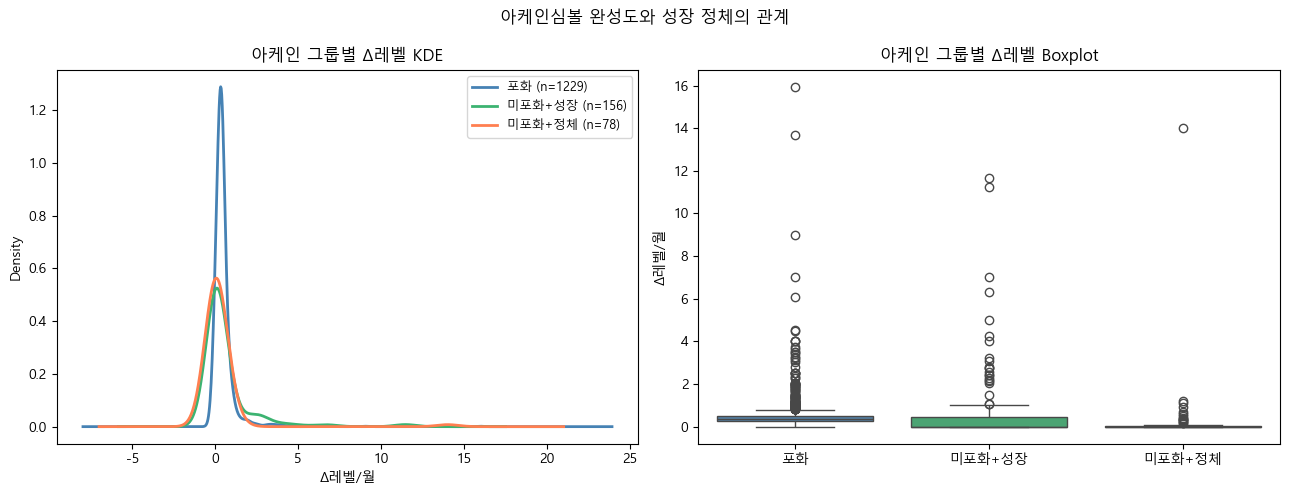

[그룹별 평균 Δ레벨]
arcane_group
미포화+성장    0.649
미포화+정체    0.278
포화        0.491


In [23]:
# 아케인 포화 그룹별 Δ레벨 비교
df_clean['arcane_group'] = '미포화+성장'
df_clean.loc[df_clean['arcane_saturated'], 'arcane_group'] = '포화'
df_clean.loc[df_clean['arcane_stagnant'], 'arcane_group'] = '미포화+정체'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
group_order_sym = ['포화', '미포화+성장', '미포화+정체']

# KDE 비교
for grp, color in zip(group_order_sym, ['steelblue', 'mediumseagreen', 'coral']):
    data = df_clean[df_clean['arcane_group'] == grp]['avg_monthly_delta_level']
    data.plot.kde(ax=axes[0], label=f'{grp} (n={len(data)})', color=color, lw=2)
axes[0].set_title('아케인 그룹별 Δ레벨 KDE')
axes[0].set_xlabel('Δ레벨/월')
axes[0].legend(fontsize=9)

# Boxplot
sns.boxplot(data=df_clean, x='arcane_group', y='avg_monthly_delta_level',
            order=group_order_sym, ax=axes[1], palette=['steelblue','mediumseagreen','coral'])
axes[1].set_title('아케인 그룹별 Δ레벨 Boxplot')
axes[1].set_xlabel('')
axes[1].set_ylabel('Δ레벨/월')

plt.suptitle('아케인심볼 완성도와 성장 정체의 관계', fontsize=12)
plt.tight_layout()
plt.show()

print('[그룹별 평균 Δ레벨]')
print(df_clean.groupby('arcane_group')['avg_monthly_delta_level'].mean().round(3).to_string())

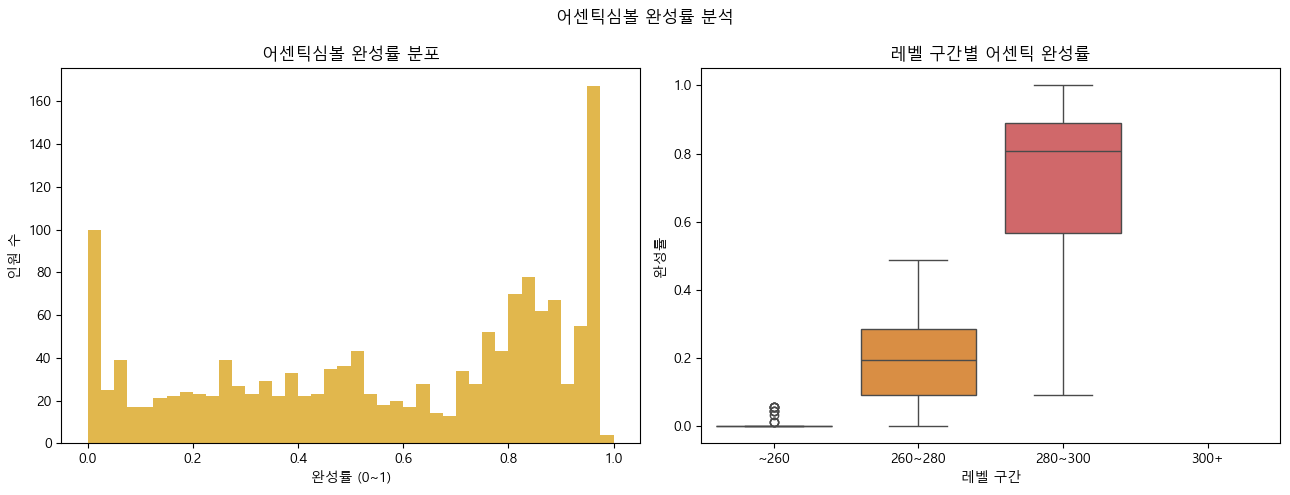

[레벨 구간별 어센틱 완성률 평균]
level_band
~260       0.005
260~280    0.200
280~300    0.733

-> 260 미만: 어센틱 콘텐츠 미접근 (0에 가까울 것)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_clean['authentic_completion'], bins=40, color='goldenrod', alpha=0.8)
axes[0].set_title('어센틱심볼 완성률 분포')
axes[0].set_xlabel('완성률 (0~1)')
axes[0].set_ylabel('인원 수')

sns.boxplot(data=df_clean, x='level_band', y='authentic_completion',
            order=['~260','260~280','280~300','300+'], ax=axes[1],
            palette=BAND_PALETTE)
axes[1].set_title('레벨 구간별 어센틱 완성률')
axes[1].set_xlabel('레벨 구간')
axes[1].set_ylabel('완성률')

plt.suptitle('어센틱심볼 완성률 분석', fontsize=12)
plt.tight_layout()
plt.show()

print('[레벨 구간별 어센틱 완성률 평균]')
print(df_clean.groupby('level_band', observed=True)['authentic_completion'].mean().round(3).to_string())
print('\n-> 260 미만: 어센틱 콘텐츠 미접근 (0에 가까울 것)')

## Sec 8. 종합 성장 정체 지수 (stagnation_score)

5개 신호를 합산한 단일 지수로 주차 유저 규모를 사전 추정한다.

In [25]:
# 각 delta 피처가 하위 25% 이하이면 정체 신호 (1점)
delta_for_stag = [
    'avg_monthly_delta_level',
    'avg_monthly_delta_combat_power',
    'avg_monthly_delta_union_level',
    'avg_monthly_delta_authentic_symbol',
]
for col in delta_for_stag:
    q25 = df_clean[col].quantile(0.25)
    key = col.replace('avg_monthly_delta_', '')
    df_clean[f'stagnant_{key}'] = (df_clean[col] <= q25).astype(int)

# arcane_stagnant (미포화+delta=0) 포함
df_clean['stagnation_score'] = (
    df_clean[[f'stagnant_{c.replace("avg_monthly_delta_","")}' for c in delta_for_stag]].sum(axis=1)
    + df_clean['arcane_stagnant'].astype(int)
)

print('[stagnation_score 분포 (0~5점)]')
score_dist = df_clean['stagnation_score'].value_counts().sort_index()
for score, cnt in score_dist.items():
    bar = '█' * int(cnt / len(df_clean) * 50)
    print(f'  {score}점: {cnt:4d}명 ({cnt/len(df_clean)*100:5.1f}%)  {bar}')

print(f'\n5점(전 피처 정체): {(df_clean["stagnation_score"]==5).sum()}명')
print(f'>=4점(강한 정체):   {(df_clean["stagnation_score"]>=4).sum()}명')
print('\n[한계] P25 기준은 임의적 — 클러스터링 결과와 반드시 비교 검증 필요')

[stagnation_score 분포 (0~5점)]
  0점:  846명 ( 57.8%)  ████████████████████████████
  1점:  204명 ( 13.9%)  ██████
  2점:   72명 (  4.9%)  ██
  3점:  125명 (  8.5%)  ████
  4점:  162명 ( 11.1%)  █████
  5점:   54명 (  3.7%)  █

5점(전 피처 정체): 54명
>=4점(강한 정체):   216명

[한계] P25 기준은 임의적 — 클러스터링 결과와 반드시 비교 검증 필요


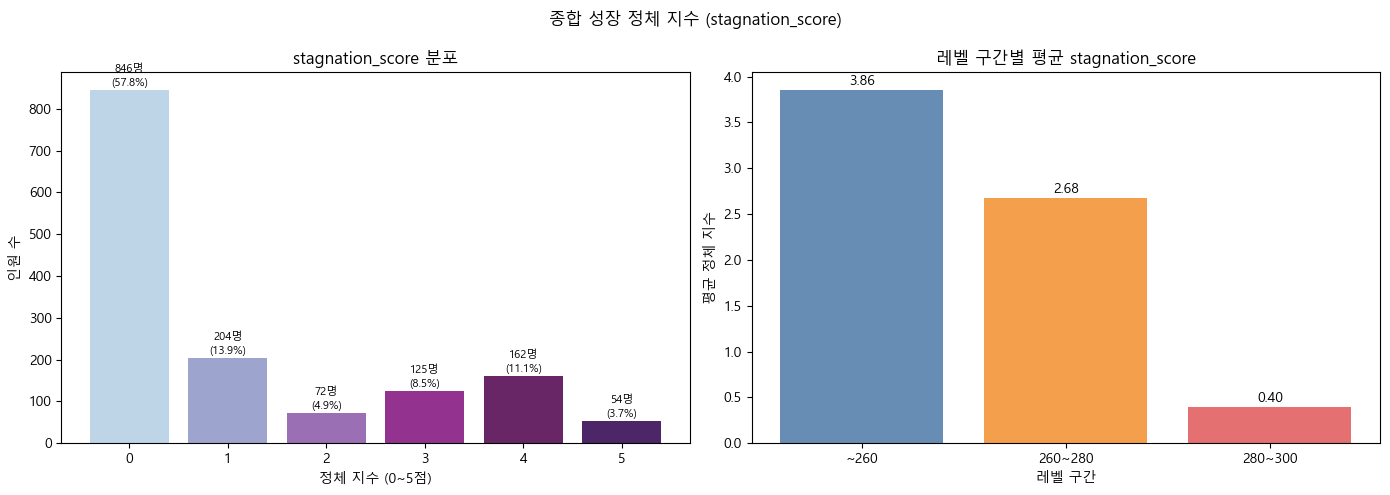

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 전체 분포
bars = axes[0].bar(
    score_dist.index.astype(str),
    score_dist.values,
    color=['#b3cde3','#8c96c6','#8856a7','#810f7c','#4d004b','#2d004b'][:len(score_dist)],
    alpha=0.85
)
for bar, cnt in zip(bars, score_dist.values):
    pct = cnt / len(df_clean) * 100
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{cnt}명\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[0].set_title('stagnation_score 분포')
axes[0].set_xlabel('정체 지수 (0~5점)')
axes[0].set_ylabel('인원 수')

# 오른쪽: 레벨 구간별 평균
band_stag = df_clean.groupby('level_band', observed=True)['stagnation_score'].mean()
bands = band_stag.index.tolist()
bcolors = [BAND_PALETTE[b] for b in bands]
axes[1].bar(bands, band_stag.values, color=bcolors, alpha=0.85)
for i, (b, v) in enumerate(zip(bands, band_stag.values)):
    axes[1].text(i, v+0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('레벨 구간별 평균 stagnation_score')
axes[1].set_xlabel('레벨 구간')
axes[1].set_ylabel('평균 정체 지수')

plt.suptitle('종합 성장 정체 지수 (stagnation_score)', fontsize=12)
plt.tight_layout()
plt.show()

## Sec 9. 가설 검증 가능성 체크리스트

EDA 결과를 바탕으로 H1/H2/H3 실현 가능성을 판단한다.

In [27]:
print('=' * 55)
print('H1 체크리스트: K-Means / DBSCAN 클러스터 분리 가능성')
print('=' * 55)

zero_arc = (df_clean['avg_monthly_delta_arcane_symbol'] == 0).mean()
neg_cp = (df_clean['avg_monthly_delta_combat_power'] < 0).mean()
valid_n = len(df_clean)
r_lu = df_clean['avg_monthly_delta_level'].corr(df_clean['avg_monthly_delta_union_level'])

print(f'\n  delta_arcane 0값 비율:  {zero_arc*100:.1f}%')
print(f'  판정: {"이진화(arcane_stagnant) 권장" if zero_arc > 0.5 else "원본 사용 가능"}')

print(f'\n  delta_cp 음수 비율:    {neg_cp*100:.1f}%')
print(f'  판정: {"Winsorize 적용" if neg_cp > 0.1 else "처리 불필요"}')

print(f'\n  유효 행 수:            {valid_n}행')
print(f'  판정: {"충분" if valid_n >= 1000 else "부족 (1000 미만)"}')

print(f'\n  delta_level-delta_union 상관:  r={r_lu:.3f}')
print(f'  판정: {"다중공선성 주의 — VIF 재확인" if abs(r_lu) > 0.5 else "상관 낮음, 독립 정보"}')

print('\n  종합 판정: 조건부 가능')
print('  (delta_arcane 이진화 + delta_cp Winsorize 전처리 후 클러스터링 실시)')

H1 체크리스트: K-Means / DBSCAN 클러스터 분리 가능성

  delta_arcane 0값 비율:  67.3%
  판정: 이진화(arcane_stagnant) 권장

  delta_cp 음수 비율:    22.3%
  판정: Winsorize 적용

  유효 행 수:            1463행
  판정: 충분

  delta_level-delta_union 상관:  r=0.348
  판정: 상관 낮음, 독립 정보

  종합 판정: 조건부 가능
  (delta_arcane 이진화 + delta_cp Winsorize 전처리 후 클러스터링 실시)


In [28]:
print('=' * 55)
print('H2 체크리스트: Chi-Square 검증 가능성')
print('=' * 55)

# 레벨 구간
parked_proxy = df_clean['avg_monthly_delta_level'] <= 0.1
ct_lv = pd.crosstab(df_clean['level_band'], parked_proxy)
_, _, _, exp_lv = chi2_contingency(ct_lv)
min_lv = exp_lv.min()
print(f'\n  레벨 4구간 기대 빈도 최솟값:  {min_lv:.2f}')
print(f'  판정: {"✓ 가능" if min_lv >= 5 else "⚠ 구간 합산 또는 Yates 보정 필요"}')

# 직업 계열
df_cls = df_clean[df_clean['class_group'] != '기타']
ct_cl = pd.crosstab(df_cls['class_group'], parked_proxy.loc[df_cls.index])
_, _, _, exp_cl = chi2_contingency(ct_cl)
min_cl = exp_cl.min()
print(f'\n  직업 5계열 기대 빈도 최솟값:  {min_cl:.2f}')
print(f'  판정: {"✓ 가능 (초보자 제외)" if min_cl >= 5 else "⚠ 추가 조정 필요"}')

print('\n  종합 판정: 가능')
print('  레벨 4구간 + 직업 5계열(초보자 제외) 기준, 기대 빈도 충족 여부 위에서 확인')

H2 체크리스트: Chi-Square 검증 가능성

  레벨 4구간 기대 빈도 최솟값:  23.24
  판정: ✓ 가능

  직업 5계열 기대 빈도 최솟값:  43.20
  판정: ✓ 가능 (초보자 제외)

  종합 판정: 가능
  레벨 4구간 + 직업 5계열(초보자 제외) 기준, 기대 빈도 충족 여부 위에서 확인


In [29]:
print('=' * 55)
print('H3 체크리스트: Feature Importance + Rule 식별 가능성')
print('=' * 55)

parked_rate = parked_proxy.mean()
stag5_rate = (df_clean['stagnation_score'] == 5).mean()

print(f'\n  주차 프록시 비율 (Δ레벨<=0.1): {parked_rate*100:.1f}%')
print(f'  stagnation_score 5점 비율:    {stag5_rate*100:.1f}%')

if parked_rate < 0.05:
    print('  클래스 불균형: ⚠ 5% 미만 -> SMOTE 또는 class_weight 권장')
elif parked_rate > 0.5:
    print('  클래스 불균형: ⚠ 50% 초과 -> 기준 재검토 필요')
else:
    print(f'  클래스 불균형: ✓ 적절한 비율 ({parked_rate*100:.1f}%)')

print('\n  피처 분산:')
for col in DELTA_COLS:
    std = df_clean[col].std()
    key = col.replace('avg_monthly_delta_', 'D')
    print(f'    {key}: std={std:.2f}')

print('\n  종합 판정: 가능 (H1 Silhouette Score > 0.4 조건부)')
print('  H3 pseudo-label 품질은 H1 클러스터링 결과에 의존함')

H3 체크리스트: Feature Importance + Rule 식별 가능성

  주차 프록시 비율 (Δ레벨<=0.1): 23.7%
  stagnation_score 5점 비율:    3.7%
  클래스 불균형: ✓ 적절한 비율 (23.7%)

  피처 분산:
    Dlevel: std=1.02
    Dcombat_power: std=9076452.47
    Dunion_level: std=73.53
    Darcane_symbol: std=2.12
    Dauthentic_symbol: std=0.77

  종합 판정: 가능 (H1 Silhouette Score > 0.4 조건부)
  H3 pseudo-label 품질은 H1 클러스터링 결과에 의존함


## Sec 10. 전처리 결정 및 클러스터링 피처 최종 확정

In [30]:
df_final = df_clean.copy()

# 1. delta_cp Winsorize (P5-P95)
cp_col = 'avg_monthly_delta_combat_power'
cp_win = winsorize(df_final[cp_col], limits=[0.05, 0.05])
df_final[cp_col] = np.array(cp_win)
print(f'1. delta_cp Winsorize(P5-P95) 적용')
print(f'   처리 후 범위: {df_final[cp_col].min():.0f} ~ {df_final[cp_col].max():.0f}')

# 2. delta_union 음수 -> 0
neg_u = (df_final['avg_monthly_delta_union_level'] < 0).sum()
df_final.loc[df_final['avg_monthly_delta_union_level'] < 0, 'avg_monthly_delta_union_level'] = 0
print(f'\n2. delta_union 음수 {neg_u}행 -> 0 처리')

# 3. delta_arcane 음수 -> 0
neg_a = (df_final['avg_monthly_delta_arcane_symbol'] < 0).sum()
df_final.loc[df_final['avg_monthly_delta_arcane_symbol'] < 0, 'avg_monthly_delta_arcane_symbol'] = 0
print(f'3. delta_arcane 음수 {neg_a}행 -> 0 처리')

print(f'\n최종 유효 행 수: {len(df_final)}행')

# 권장 피처 세트
CLUSTER_FEATURES_A = [
    'avg_monthly_delta_level',
    'avg_monthly_delta_combat_power',
    'avg_monthly_delta_union_level',
    'avg_monthly_delta_authentic_symbol',
    'arcane_stagnant',  # arcane_delta 이진화 대체
]
CLUSTER_FEATURES_B = DELTA_COLS.copy()  # arcane 원본 유지

print(f'\n피처 세트 A (arcane 이진화): {CLUSTER_FEATURES_A}')
print(f'피처 세트 B (arcane 원본):   {CLUSTER_FEATURES_B}')
print('\n-> 두 세트 모두 적용 후 Silhouette Score로 비교 권장')

1. delta_cp Winsorize(P5-P95) 적용
   처리 후 범위: -3747630 ~ 23111590

2. delta_union 음수 3행 -> 0 처리
3. delta_arcane 음수 1행 -> 0 처리

최종 유효 행 수: 1463행

피처 세트 A (arcane 이진화): ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power', 'avg_monthly_delta_union_level', 'avg_monthly_delta_authentic_symbol', 'arcane_stagnant']
피처 세트 B (arcane 원본):   ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power', 'avg_monthly_delta_union_level', 'avg_monthly_delta_arcane_symbol', 'avg_monthly_delta_authentic_symbol']

-> 두 세트 모두 적용 후 Silhouette Score로 비교 권장


In [31]:
print('=' * 60)
print('EDA 종합 요약')
print('=' * 60)

print(f'\n[데이터]')
print(f'  유효 샘플: {len(df_final)}행 (원본 {len(df)}행 -> {len(df)-len(df_final)}행 제거)')
print(f'  주차 프록시 (Δ레벨<=0.1): {(df_final["avg_monthly_delta_level"]<=0.1).mean()*100:.1f}%')
print(f'  280+ 레벨 집중도:         {(df_final["level"]>=280).mean()*100:.1f}%  (샘플링 편향)')
print(f'  아케인 포화율:            {df_final["arcane_saturated"].mean()*100:.1f}%')
print(f'  delta_arcane 0값 비율:    {(df_final["avg_monthly_delta_arcane_symbol"]==0).mean()*100:.1f}%')
print(f'  stagnation_score 5점:    {(df_final["stagnation_score"]==5).sum()}명')

print(f'\n[가설 외 발견 인사이트]')
print('  1. 아케인심볼 포화율 높음 -> delta_arcane 이진 변수화 권장')
print('  2. log_exp-authentic_symbol 강한 상관 -> 두 변수는 중복 정보 가능성')
print('  3. 280+ 구간 과집중 -> H2 낮은 레벨 구간 샘플 제약 확인 필요')
print('  4. exp_rank_within_level 신호 -> 클러스터 교차 검증으로 활용 가능')
print('  5. stagnation_score로 주차 유저 하한 사전 추정 가능')

print(f'\n[H1/H2/H3 가능 여부]')
print('  H1: 조건부 가능 (arcane 이진화 + cp Winsorize 전처리 후)')
print('  H2: 가능 (레벨 4구간 + 직업 5계열, 기대 빈도 위에서 확인)')
print('  H3: 가능 (H1 Silhouette Score > 0.4 조건부)')

EDA 종합 요약

[데이터]
  유효 샘플: 1463행 (원본 1497행 -> 34행 제거)
  주차 프록시 (Δ레벨<=0.1): 23.7%
  280+ 레벨 집중도:         75.7%  (샘플링 편향)
  아케인 포화율:            84.0%
  delta_arcane 0값 비율:    67.4%
  stagnation_score 5점:    54명

[가설 외 발견 인사이트]
  1. 아케인심볼 포화율 높음 -> delta_arcane 이진 변수화 권장
  2. log_exp-authentic_symbol 강한 상관 -> 두 변수는 중복 정보 가능성
  3. 280+ 구간 과집중 -> H2 낮은 레벨 구간 샘플 제약 확인 필요
  4. exp_rank_within_level 신호 -> 클러스터 교차 검증으로 활용 가능
  5. stagnation_score로 주차 유저 하한 사전 추정 가능

[H1/H2/H3 가능 여부]
  H1: 조건부 가능 (arcane 이진화 + cp Winsorize 전처리 후)
  H2: 가능 (레벨 4구간 + 직업 5계열, 기대 빈도 위에서 확인)
  H3: 가능 (H1 Silhouette Score > 0.4 조건부)
